In [17]:
import numpy as np
import gvar as gv
import h5py
import matplotlib.pyplot as plt
from cycler import cycler

In [18]:
ensemble = "D251"
base_path = f"/hdd/data/ensemble_data/{ensemble}/c2pt"
file_name = f"{ensemble}_c2pt_jkn.h5"
nmax_values = [0,1,2,3,4,5,6,8]
c2pt_per_nmax = {}
for nmax in nmax_values:
    with h5py.File(f"{base_path}/{file_name}", "r") as f:
        c2pt_per_nmax[nmax] = f[f"/c2pt/nsquare_{nmax}/fwd_bwd_avg"][()]

In [19]:
# HARDCODE FOR NOW
fit_results = {
    0: {"fit_range": [16, 44], "Eavg": gv.gvar("0.33831(70)"), "Efit": gv.gvar("0.33821(58)"), "Econt": gv.gvar("0.33821(58)"), "phat": 0.707},
    1: {"fit_range": [16, 44], "Eavg": gv.gvar("0.35191(77)"), "Efit": gv.gvar("0.35197(61)"), "Econt": gv.gvar("0.35217(56)"), "phat": 0.754},
    2: {"fit_range": [16, 42], "Eavg": gv.gvar("0.3651(10)"),  "Efit": gv.gvar("0.36517(71)"), "Econt": gv.gvar("0.36560(54)"), "phat": 0.631},
    3: {"fit_range": [16, 42], "Eavg": gv.gvar("0.3779(12)"),  "Efit": gv.gvar("0.37775(89)"), "Econt": gv.gvar("0.37855(52)"), "phat": 0.612},
    4: {"fit_range": [16, 39], "Eavg": gv.gvar("0.3895(17)"),  "Efit": gv.gvar("0.3898(12)"),  "Econt": gv.gvar("0.39107(50)"), "phat": 0.644},
    5: {"fit_range": [16, 36], "Eavg": gv.gvar("0.4004(24)"),  "Efit": gv.gvar("0.4010(14)"),  "Econt": gv.gvar("0.40321(49)"), "phat": 0.499},
    6: {"fit_range": [16, 34], "Eavg": gv.gvar("0.4112(27)"),  "Efit": gv.gvar("0.4112(18)"),  "Econt": gv.gvar("0.41499(47)"), "phat": 0.496},
    8: {"fit_range": [15, 29], "Eavg": gv.gvar("0.436(19)"),   "Efit": gv.gvar("0.4319(26)"),  "Econt": gv.gvar("0.43760(45)"), "phat": 0.451},
}

In [20]:
plt.rcParams.update({
    "font.size": 18,
    "font.family": "computer modern",
    "text.usetex": True,
    "figure.dpi": 200,
    "axes.prop_cycle":
        cycler(color=[
            "#1E6EF4",
            "#ff8d28",
            "#34C759",
            "#E7124D",
        ])
})
blue       = "#1E6EF4"
markersize = 10
capsize    = 6
linewidth  = 2

/tmp/ipykernel_122822/2965911969.py:11: RuntimeWarning: invalid value encountered in log
  Eeff_data = np.log(data[:, :-1] / data[:, 1:])


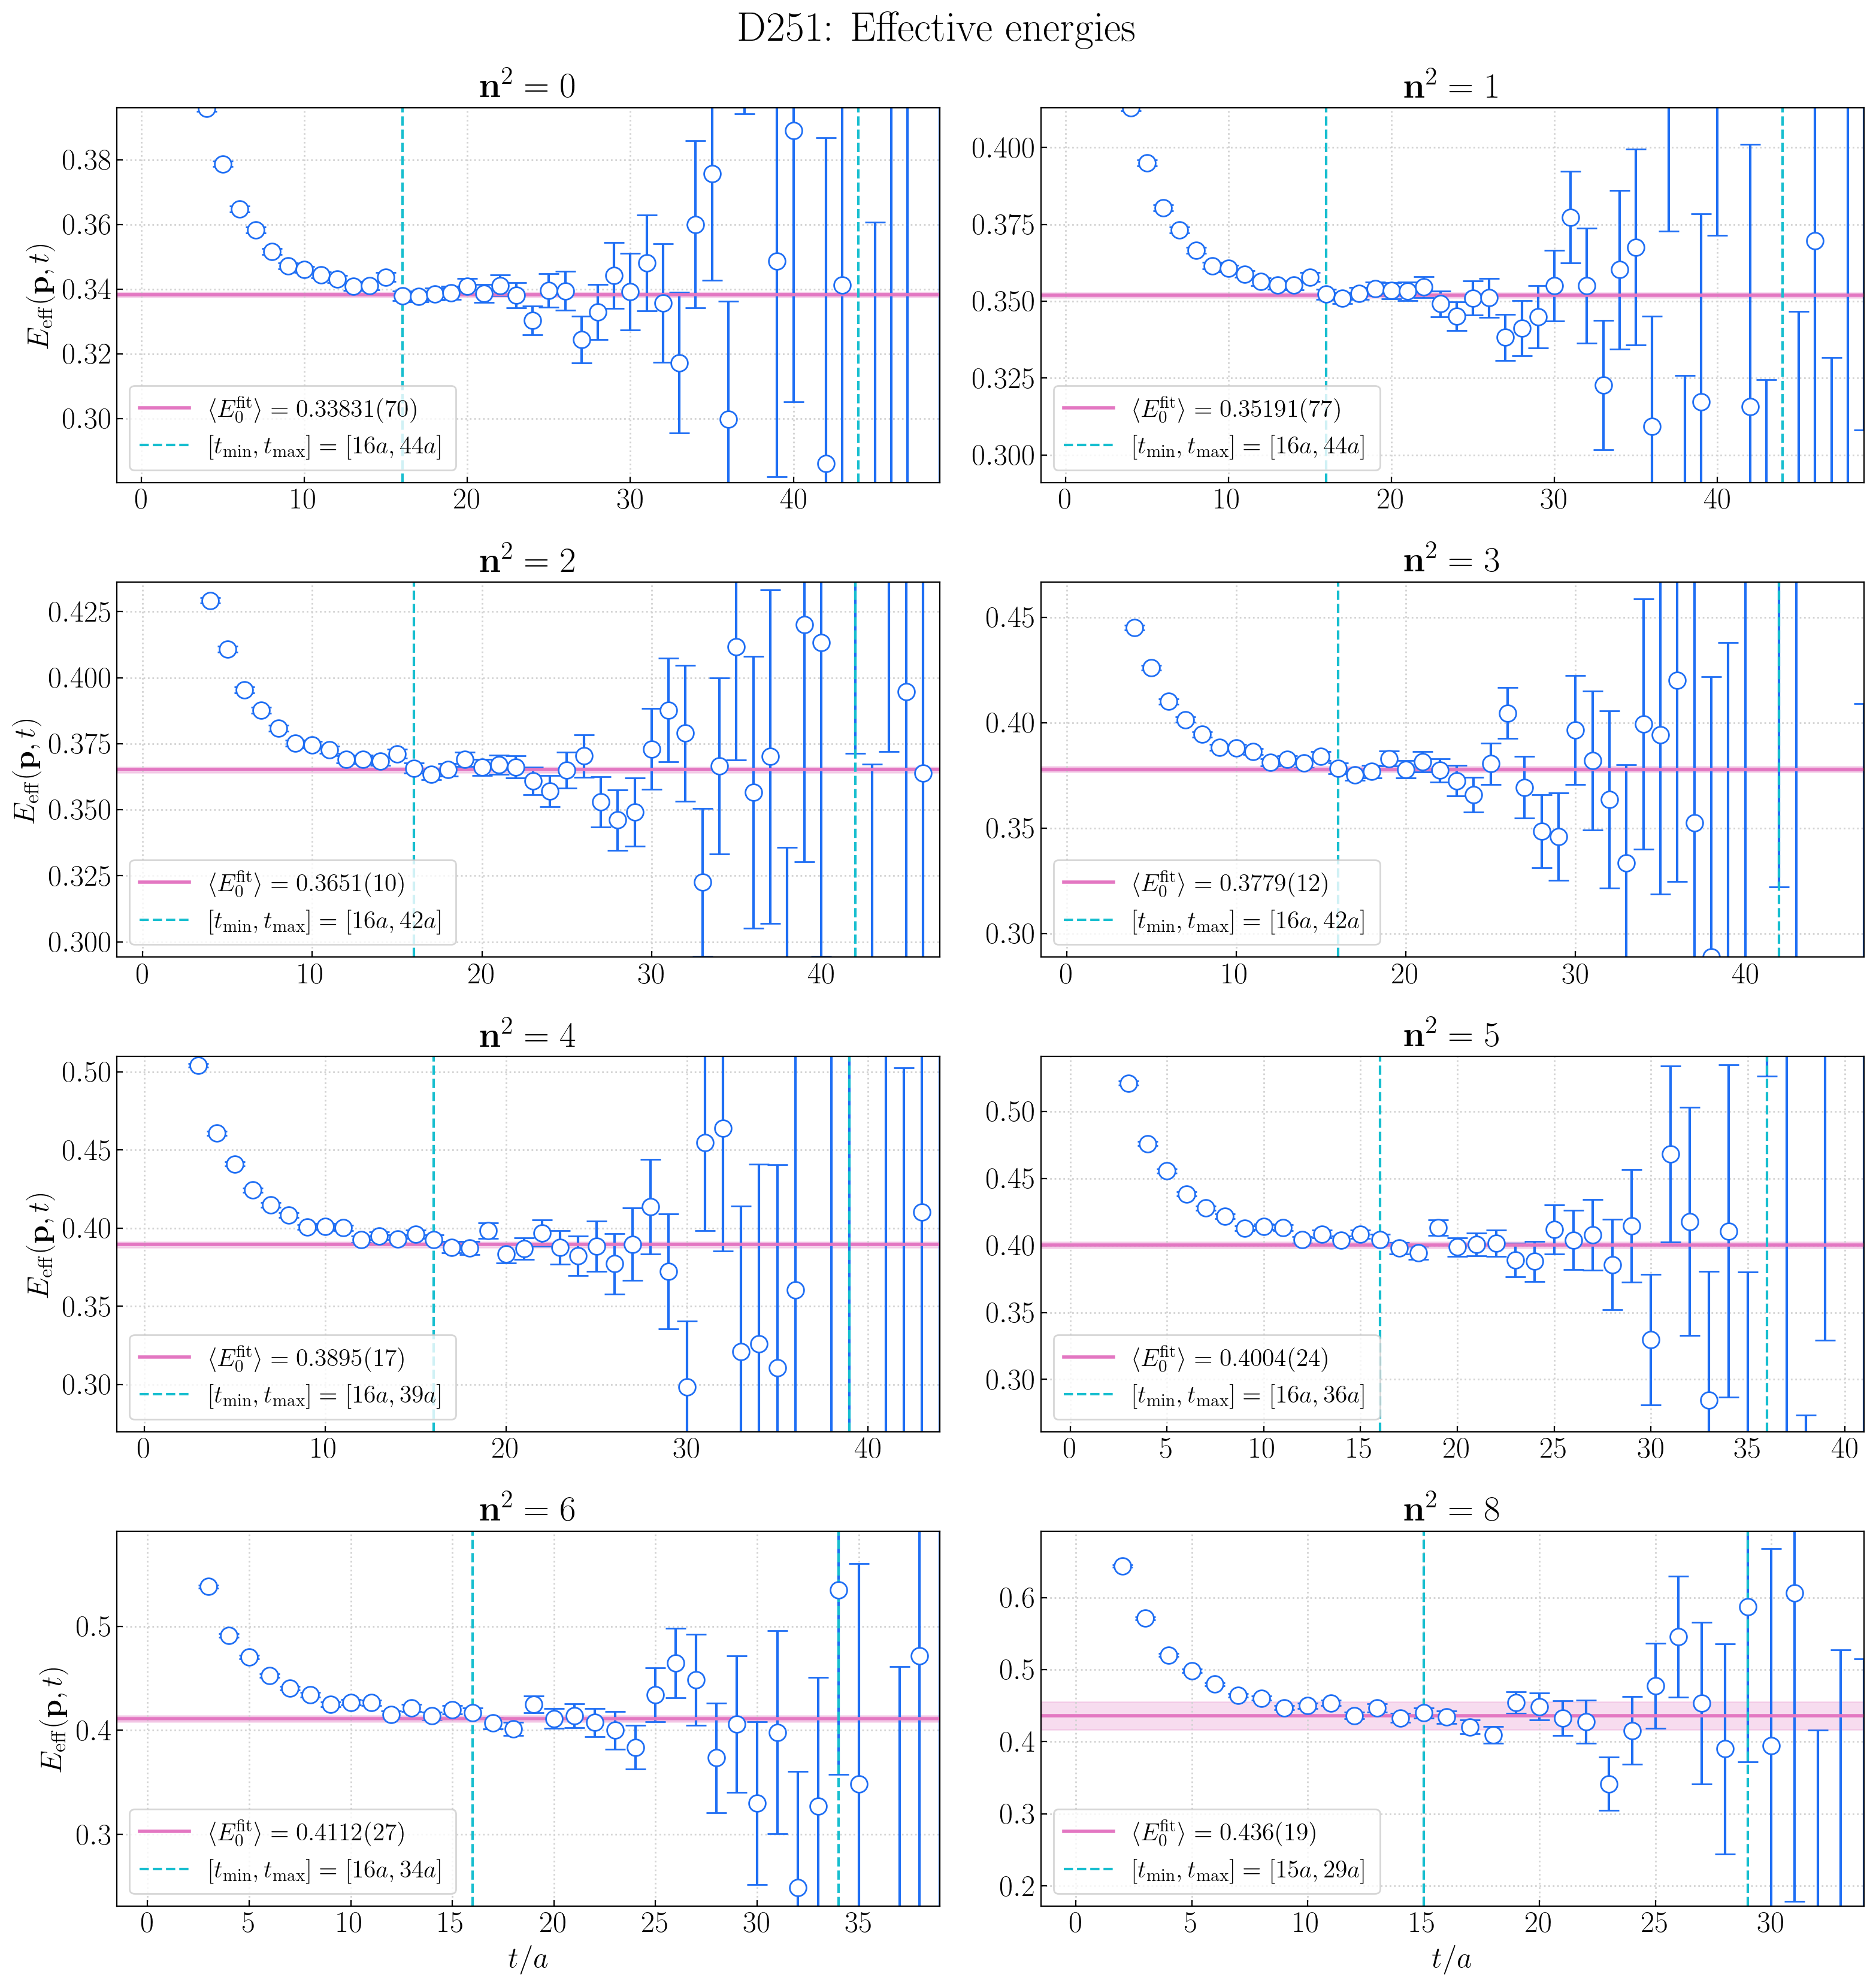

In [30]:
fig, axs = plt.subplots(4, 2, figsize=(16, 17))  # removed sharey=True
axs_flat = axs.flatten()

n_jkn = c2pt_per_nmax[1].shape[0]

for i, nmax in enumerate(nmax_values):
    ax   = axs_flat[i]
    data = c2pt_per_nmax[nmax] 

    # --- effective energy per resample ---
    Eeff_data = np.log(data[:, :-1] / data[:, 1:])
    Eeff_avg  = np.mean(Eeff_data, axis=0)
    Eeff_err  = np.std(Eeff_data, axis=0) * np.sqrt(n_jkn - 1)
    t = np.arange(len(Eeff_avg))

    # model average
    Eavg = fit_results[nmax]["Eavg"]
    Eavg_est = gv.mean(Eavg)
    Eavg_err = gv.sdev(Eavg)

    # best fit
    Efit = fit_results[nmax]["Efit"]
    Efit_est = gv.mean(Efit)
    Efit_err = gv.sdev(Efit)

    t_min, t_max = fit_results[nmax]["fit_range"]

    ax.errorbar(t, Eeff_avg, Eeff_err,
                fmt="o", mfc="white", color=blue,
                markersize=markersize, capsize=capsize)


    # ax.axhspan(Efit_est - Efit_err, Efit_est + Efit_err,
    #            color="tab:pink", alpha=0.25)
    # ax.axhline(Efit_est, color="tab:pink", linewidth=linewidth,
    #            label=rf"$E_0^{{\rm fit}} = {Efit}$")

    ax.axhspan(Eavg_est - Eavg_err, Eavg_est + Eavg_err,
               color="tab:pink", alpha=0.25)
    ax.axhline(Eavg_est, color="tab:pink", linewidth=linewidth,
               label=rf"$\langle E_0^{{\rm fit}}\rangle = {Eavg}$")

      # --- fit window markers ---
    ax.axvline(t_min, color="tab:cyan", linestyle="--", linewidth=1.5,
               label=rf"$[t_{{\min}}, t_{{\max}}] = [{t_min}a, {t_max}a]$")
    ax.axvline(t_max, color="tab:cyan", linestyle="--", linewidth=1.5)

    # --- cosmetics: zoom to plateau ---
    y_pad = max(100 * Efit_err, 0.02)
    ax.set_ylim(Efit_est - y_pad, Efit_est + y_pad)
    ax.set_xlim(-1.5, t_max + 5)
    ax.set_title(rf"$\mathbf{{n}}^2 = {nmax}$")
    if i >= len(nmax_values) - 2:
        ax.set_xlabel(r"$t/a$")
    if i % 2 == 0:
        ax.set_ylabel(r"$E_{\mathrm{eff}}(\mathbf{p}, t)$")
    ax.legend(fontsize=15)
    ax.grid(color="lightgrey", linestyle=":", linewidth=1)
    ax.tick_params(direction="in")

fig.suptitle(rf"$\mathrm{{{ensemble}}}$: Effective energies", fontsize=25)
fig.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig(f"/home/ck/phd/code/hadrana/plots/{ensemble}_effective_energies.pdf")

fig.tight_layout()
plt.show()